# 04 – Análise Exploratória e Visualização

**Objetivo:** Realizar a análise exploratória da base de modelagem (`base_modelagem.csv`), cobrindo:
- Estatísticas descritivas gerais
- Análise de variáveis qualitativas (frequências, tabelas de contingência)
- Análise de variáveis quantitativas (idade, tempo de permanência, tempo de sobrevida)
- Visualizações (histograma, boxplot, barras, mapa de calor)

**Base:** `data/processed/base_modelagem.csv`

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Configurações gráficas estritas conforme normas da instituição
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 11,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_style("white")
def enforce_tcc_style():
    import matplotlib.pyplot as plt
    import seaborn as sns
    try:
        plt.grid(False)
        sns.despine(top=True, right=True, left=False, bottom=False)
        for ax_ in plt.gcf().axes:
            ax_.grid(False)
            ax_.spines['top'].set_visible(False)
            ax_.spines['right'].set_visible(False)
            ax_.spines['bottom'].set_linewidth(1.5)
            ax_.spines['bottom'].set_color('black')
            ax_.spines['left'].set_linewidth(1.5)
            ax_.spines['left'].set_color('black')
            ax_.tick_params(colors='black', width=1.5)
            if ax_.get_title(): ax_.set_title('')
    except Exception: pass


In [3]:
import pandas as pd
import numpy as np

# Como a base de modelagem (reduzida) não possui a coluna de dias de permanência 
# (para evitar data leakage), vamos carregar a base completa (com permanência) para a Tabela 2.
df_completo = pd.read_csv('../data/processed/base_modelagem.csv', low_memory=False)

# Dicionários para mapeamento
map_desfecho = {0: 'Alta (0)', 1: 'Óbito (1)'}
df_completo['Desfecho'] = df_completo['indicador_obito'].map(map_desfecho)

print("=================================================================")
print("Tabela 2. Estatísticas descritivas da amostra (idade, permanência, sexo)")
print("=================================================================\n")

# 1. IDADE
print("--- IDADE (Anos) ---")
desc_idade = df_completo.groupby('Desfecho')['idade'].agg(['count', 'mean', 'std', 'median']).round(1)
desc_idade.loc['Geral (All)'] = df_completo['idade'].agg(['count', 'mean', 'std', 'median']).round(1)
display(desc_idade)

# 2. TEMPO DE PERMANÊNCIA
print("\n--- TEMPO DE PERMANÊNCIA (Dias) ---")
desc_perm = df_completo.groupby('Desfecho')['dias_permanencia_cod'].agg(['count', 'mean', 'std', 'median']).round(1)
desc_perm.loc['Geral (All)'] = df_completo['dias_permanencia_cod'].agg(['count', 'mean', 'std', 'median']).round(1)
display(desc_perm)

# 3. SEXO
print("\n--- SEXO (Contagem e %) ---")
crosstab_count = pd.crosstab(df_completo['sexo'], df_completo['Desfecho'], margins=True, margins_name='Geral (All)')
crosstab_pct_alta = (crosstab_count['Alta (0)'] / crosstab_count['Alta (0)']['Geral (All)'] * 100).round(2)
crosstab_pct_obito = (crosstab_count['Óbito (1)'] / crosstab_count['Óbito (1)']['Geral (All)'] * 100).round(2)
crosstab_pct_geral = (crosstab_count['Geral (All)'] / crosstab_count['Geral (All)']['Geral (All)'] * 100).round(2)

crosstab_final = pd.DataFrame({
    'Alta (N)': crosstab_count['Alta (0)'],
    'Alta (%)': crosstab_pct_alta,
    'Óbito (N)': crosstab_count['Óbito (1)'],
    'Óbito (%)': crosstab_pct_obito,
    'Geral (N)': crosstab_count['Geral (All)'],
    'Geral (%)': crosstab_pct_geral
})
display(crosstab_final)


Tabela 2. Estatísticas descritivas da amostra (idade, permanência, sexo)

--- IDADE (Anos) ---


,count,mean,std,median
Desfecho,,,,
Alta (0),376410.0,62.1,12.1,62.0
Óbito (1),38957.0,69.4,12.2,70.0
Geral (All),415367.0,62.8,12.3,63.0



--- TEMPO DE PERMANÊNCIA (Dias) ---


,count,mean,std,median
Desfecho,,,,
Alta (0),376410.0,7.3,8.5,5.0
Óbito (1),38957.0,6.2,9.6,2.0
Geral (All),415367.0,7.2,8.6,4.0



--- SEXO (Contagem e %) ---


,Alta (N),Alta (%),Óbito (N),Óbito (%),Geral (N),Geral (%)
sexo,,,,,,
Feminino,133782,35.54,16878,43.32,150660,36.27
Masculino,242628,64.46,22079,56.68,264707,63.73
Geral (All),376410,100.00,38957,100.00,415367,100.00


## 0. Imports e Configurações

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Estilo dos gráficos
# sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1) # SOBRESCRITO PELO TCC
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../data/processed/base_modelagem.csv')
FIG_PATH  = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)

print('Bibliotecas carregadas com sucesso.')

df = pd.read_csv(DATA_PATH)

Bibliotecas carregadas com sucesso.


/tmp/ipykernel_456090/3596050626.py:19: DtypeWarning: Columns (102,108,109,250) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


## 1. Carregamento e Pré-processamento Inicial

In [5]:
# Compatibilidade com nomes gerados pelo ETL
if 'data_internacao_cod' in df.columns:
    df = df.rename(columns={'data_internacao_cod': 'data_internacao', 'data_saida_cod': 'data_saida'})

df['data_internacao'] = pd.to_datetime(df['data_internacao'], errors='coerce')
df['data_saida'] = pd.to_datetime(df['data_saida'], errors='coerce')

# Tempo de sobrevida hospitalar (dias entre entrada e saída)
df['tempo_sobrevida'] = (df['data_saida'] - df['data_internacao']).dt.days

# Garantir numéricos importantes
df['idade'] = pd.to_numeric(df['idade'], errors='coerce')
df['dias_permanencia'] = pd.to_numeric(df.get('quantidade_diarias', df.get('dias_permanencia', 0)), errors='coerce')

# ----- Mapeamentos de categorias -----
df['indicador_obito'] = pd.to_numeric(df['indicador_obito'], errors='coerce')
df['desfecho_label']  = df['indicador_obito'].map({0.0: 'Alta', 1.0: 'Óbito', 0: 'Alta', 1: 'Óbito'})

# As colunas abaixo já foram traduzidas no ETL (Notebook 02)! 
df['sexo_label']      = df['sexo']
df['raca_label']      = df['raca_cor']
df['carater_label']   = df['carater_internacao']

# Natureza jurídica — agrupamento em macrocategorias IBGE
# A coluna natureza_juridica_macro já foi processada no Notebook 02 (ETL) com segurança!
if 'natureza_juridica_macro' in df.columns:
    df['natureza_label'] = df['natureza_juridica_macro']
else:
    df['natureza_label'] = 'Desconhecida'

# ----- Faixa etária -----
bins   = [0, 39, 49, 59, 69, 79, 200]
labels = ['<40', '40–49', '50–59', '60–69', '70–79', '80+']
df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=True)

# ----- Filtro adultos (garante consistência) -----
df = df[df['idade'] >= 18].copy()

print(f'Base carregada: {df.shape[0]:,} internações | {df.shape[1]} colunas')
df[['desfecho_label','sexo_label','raca_label','carater_label',
    'natureza_label','faixa_etaria','tempo_sobrevida']].head(3)


Base carregada: 415,367 internações | 666 colunas


,desfecho_label,sexo_label,raca_label,carater_label,natureza_label,faixa_etaria,tempo_sobrevida
0,Alta,Feminino,Preta,Urgência,Desconhecida,50–59,28
1,Óbito,Feminino,Sem informação,Urgência,Desconhecida,60–69,12
2,Óbito,Feminino,Sem informação,Urgência,Desconhecida,60–69,8


## 2. Estatísticas Descritivas Gerais

In [6]:
n_internacoes = len(df)
n_hospitais   = df['codigo_cnes'].nunique()
n_obitos      = df['indicador_obito'].sum()
taxa_letali   = (n_obitos / n_internacoes) * 100

print('=' * 50)
print('  DIMENSÃO DA BASE PÓS-MERGE')
print('=' * 50)
print(f'  Nº de internações (pacientes) : {n_internacoes:>8,}')
print(f'  Nº de hospitais (CNES únicos) : {n_hospitais:>8,}')
print()
print('  DISTRIBUIÇÃO DO DESFECHO')
print('-' * 50)
dest = df['desfecho_label'].value_counts()
dest_pct = df['desfecho_label'].value_counts(normalize=True) * 100
for cat in dest.index:
    print(f'  {cat:<8}: {dest[cat]:>6,}  ({dest_pct[cat]:5.2f}%)')
print()
print(f'  TAXA DE LETALIDADE HOSPITALAR : {taxa_letali:.2f}%')
print('=' * 50)

  DIMENSÃO DA BASE PÓS-MERGE
  Nº de internações (pacientes) :  415,367
  Nº de hospitais (CNES únicos) :      506

  DISTRIBUIÇÃO DO DESFECHO
--------------------------------------------------
  Alta    : 376,410  (90.62%)
  Óbito   : 38,957  ( 9.38%)

  TAXA DE LETALIDADE HOSPITALAR : 9.38%


## 3. Análise de Variáveis Qualitativas

### 3.1 Frequências absolutas e relativas

In [7]:
def tabela_freq(serie, titulo):
    """Retorna DataFrame com frequência absoluta e relativa."""
    freq  = serie.value_counts(dropna=False)
    pct   = serie.value_counts(normalize=True, dropna=False) * 100
    tbl   = pd.DataFrame({'n': freq, '%': pct.round(2)})
    tbl.index.name = titulo
    return tbl

variaveis_quali = {
    'Sexo':                  'sexo_label',
    'Raça/Cor':              'raca_label',
    'Caráter do atendimento':'carater_label',
    'Natureza jurídica':     'natureza_label',
}

for titulo, coluna in variaveis_quali.items():
    print(f'\n--- {titulo} ---')
    display(tabela_freq(df[coluna], titulo))


--- Sexo ---


,n,%
Sexo,,
Masculino,264707,63.73
Feminino,150660,36.27



--- Raça/Cor ---


,n,%
Raça/Cor,,
Branca,240660,57.94
Parda,105588,25.42
Sem informação,45184,10.88
Preta,19999,4.81
Amarela,3900,0.94
Indígena,36,0.01



--- Caráter do atendimento ---


,n,%
Caráter do atendimento,,
Urgência,376194,90.57
Eletivo,39173,9.43



--- Natureza jurídica ---


,n,%
Natureza jurídica,,
Desconhecida,415367,100.0


### 3.2 Tabelas de contingência (desfecho × variável)

In [8]:
def contingencia(df, var_linha, var_col='desfecho_label', normalize='index'):
    """Tabela de contingência com % por linha."""
    ct = pd.crosstab(
        df[var_linha], df[var_col],
        margins=True, margins_name='Total'
    )
    ct_pct = pd.crosstab(
        df[var_linha], df[var_col],
        normalize=normalize
    ) * 100
    return ct, ct_pct.round(2)

# Desfecho × Sexo
print('=== Desfecho × Sexo ===')
ct, ct_pct = contingencia(df, 'sexo_label')
display(ct)
print('% por linha:')
display(ct_pct)

# Desfecho × Faixa etária
print('\n=== Desfecho × Faixa Etária ===')
ct2, ct_pct2 = contingencia(df, 'faixa_etaria')
display(ct2)
print('% por linha:')
display(ct_pct2)

# Desfecho × Caráter do atendimento
print('\n=== Desfecho × Caráter do Atendimento ===')
ct3, ct_pct3 = contingencia(df, 'carater_label')
display(ct3)
print('% por linha:')
display(ct_pct3)

# Desfecho × Raça/Cor
print('\n=== Desfecho × Raça/Cor ===')
ct4, ct_pct4 = contingencia(df, 'raca_label')
display(ct4)
print('% por linha:')
display(ct_pct4)

=== Desfecho × Sexo ===


desfecho_label,Alta,Óbito,Total
sexo_label,,,
Feminino,133782,16878,150660
Masculino,242628,22079,264707
Total,376410,38957,415367


% por linha:


desfecho_label,Alta,Óbito
sexo_label,,
Feminino,88.80,11.20
Masculino,91.66,8.34



=== Desfecho × Faixa Etária ===


...

desfecho_label,Alta,Óbito
carater_label,,
Eletivo,95.81,4.19
Urgência,90.08,9.92



=== Desfecho × Raça/Cor ===


desfecho_label,Alta,Óbito,Total
raca_label,,,
Amarela,3509,391,3900
Branca,217848,22812,240660
Indígena,34,2,36
Parda,96808,8780,105588
Preta,18295,1704,19999
Sem informação,39916,5268,45184
Total,376410,38957,415367


% por linha:


desfecho_label,Alta,Óbito
raca_label,,
Amarela,89.97,10.03
Branca,90.52,9.48
Indígena,94.44,5.56
Parda,91.68,8.32
Preta,91.48,8.52
Sem informação,88.34,11.66


## 4. Análise de Variáveis Quantitativas

### 4.1 Idade

In [9]:
print('=== Estatísticas de Idade ===')
stats_idade = df['idade'].describe(percentiles=[0.25, 0.5, 0.75])
print(f"  Média    : {stats_idade['mean']:.2f} anos")
print(f"  Mediana  : {stats_idade['50%']:.1f} anos")
print(f"  Desvio-p : {stats_idade['std']:.2f}")
print(f"  Q1       : {stats_idade['25%']:.1f}")
print(f"  Q3       : {stats_idade['75%']:.1f}")
print(f"  Mín      : {stats_idade['min']:.0f}")
print(f"  Máx      : {stats_idade['max']:.0f}")

print('\n--- Por desfecho ---')
display(df.groupby('desfecho_label')['idade'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))

=== Estatísticas de Idade ===
  Média    : 62.81 anos
  Mediana  : 63.0 anos
  Desvio-p : 12.33
  Q1       : 55.0
  Q3       : 71.0
  Mín      : 18
  Máx      : 99

--- Por desfecho ---


,count,mean,std,min,25%,50%,75%,max
desfecho_label,,,,,,,,
Alta,376410.0,62.13,12.14,18.0,54.0,62.0,70.0,99.0
Óbito,38957.0,69.43,12.19,18.0,61.0,70.0,78.0,99.0


### 4.2 Tempo de permanência

In [10]:
print('=== Estatísticas de Tempo de Permanência (dias) ===')
stats_perm = df['dias_permanencia'].describe(percentiles=[0.25, 0.5, 0.75])
print(f"  Média    : {stats_perm['mean']:.2f} dias")
print(f"  Mediana  : {stats_perm['50%']:.1f} dias")
print(f"  Desvio-p : {stats_perm['std']:.2f}")
print(f"  Q1 / Q3  : {stats_perm['25%']:.1f} / {stats_perm['75%']:.1f}")

print('\n--- Por desfecho ---')
display(df.groupby('desfecho_label')['dias_permanencia'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))

=== Estatísticas de Tempo de Permanência (dias) ===
  Média    : 5.67 dias
  Mediana  : 3.0 dias
  Desvio-p : 7.76
  Q1 / Q3  : 1.0 / 7.0

--- Por desfecho ---


,count,mean,std,min,25%,50%,75%,max
desfecho_label,,,,,,,,
Alta,376410.0,5.84,7.82,0.0,1.0,3.0,7.0,247.0
Óbito,38957.0,3.95,6.96,0.0,1.0,2.0,4.0,156.0


### 4.3 Tempo de sobrevida hospitalar

In [11]:
print('=== Tempo de Sobrevida Hospitalar (data_saida – data_internacao, em dias) ===')
print(f"  Valores ausentes : {df['tempo_sobrevida'].isna().sum()}")
stats_sob = df['tempo_sobrevida'].describe(percentiles=[0.25, 0.5, 0.75])
print(f"  Média    : {stats_sob['mean']:.2f} dias")
print(f"  Mediana  : {stats_sob['50%']:.1f} dias")
print(f"  Desvio-p : {stats_sob['std']:.2f}")
print(f"  Q1 / Q3  : {stats_sob['25%']:.1f} / {stats_sob['75%']:.1f}")

print('\n--- Por desfecho ---')
display(df.groupby('desfecho_label')['tempo_sobrevida'].describe(percentiles=[0.25, 0.5, 0.75]).round(2))

=== Tempo de Sobrevida Hospitalar (data_saida – data_internacao, em dias) ===
  Valores ausentes : 0
  Média    : 7.18 dias
  Mediana  : 4.0 dias
  Desvio-p : 8.64
  Q1 / Q3  : 2.0 / 9.0

--- Por desfecho ---


,count,mean,std,min,25%,50%,75%,max
desfecho_label,,,,,,,,
Alta,376410.0,7.28,8.52,0.0,2.0,5.0,9.0,247.0
Óbito,38957.0,6.19,9.65,0.0,1.0,2.0,8.0,188.0


### 4.4 Tabelas Consolidadas (Formatadas para o TCC)

In [12]:
# Tabela 1: Letalidade por faixa etária
tabela_fx = df.groupby('faixa_etaria', observed=True).agg(
    n_total=('indicador_obito', 'count'),
    n_obitos=('indicador_obito', 'sum')
).reset_index()

tabela_fx['taxa_letalidade'] = (tabela_fx['n_obitos'] / tabela_fx['n_total'] * 100).round(2)
tabela_fx.columns = ['Faixa Etária', 'Total de Internações (N)', 'Óbitos (N)', 'Taxa de Letalidade (%)']

# Exibir como HTML formatado
tabela_fx.style.set_caption("<b>Taxa de letalidade hospitalar por Infarto Agudo do Miocárdio segundo faixa etária no estado de São Paulo (2025).</b>").format({'Taxa de Letalidade (%)': '{:.2f}%'}).hide(axis="index")

Faixa Etária,Total de Internações (N),Óbitos (N),Taxa de Letalidade (%)
<40,13543,501,3.70%
40–49,43910,1787,4.07%
50–59,102749,5590,5.44%
60–69,132368,11076,8.37%
70–79,86236,11555,13.40%
80+,36561,8448,23.11%


In [13]:
# Tabela 2: Tempo de permanência por desfecho
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)

tabela_perm = df.groupby('desfecho_label').agg(
    media=('dias_permanencia', 'mean'),
    mediana=('dias_permanencia', 'median'),
    q25=('dias_permanencia', q1),
    q75=('dias_permanencia', q3)
).reset_index()

tabela_perm['iqr_str'] = tabela_perm['q25'].astype(int).astype(str) + " – " + tabela_perm['q75'].astype(int).astype(str)
tabela_perm = tabela_perm[['desfecho_label', 'media', 'mediana', 'iqr_str']]
tabela_perm.columns = ['Desfecho Clínico', 'Média (dias)', 'Mediana (dias)', 'Intervalo Interquartil (IQR)']
tabela_perm['Média (dias)'] = tabela_perm['Média (dias)'].round(2)

tabela_perm.style.set_caption("<b>Distribuição do tempo de permanência hospitalar (em dias) segundo o desfecho clínico.</b>").hide(axis="index")

Desfecho Clínico,Média (dias),Mediana (dias),Intervalo Interquartil (IQR)
Alta,5.840000,3.000000,1 – 7
Óbito,3.950000,2.000000,1 – 4


## 5. Visualizações

### 5.1 Histograma de Idade

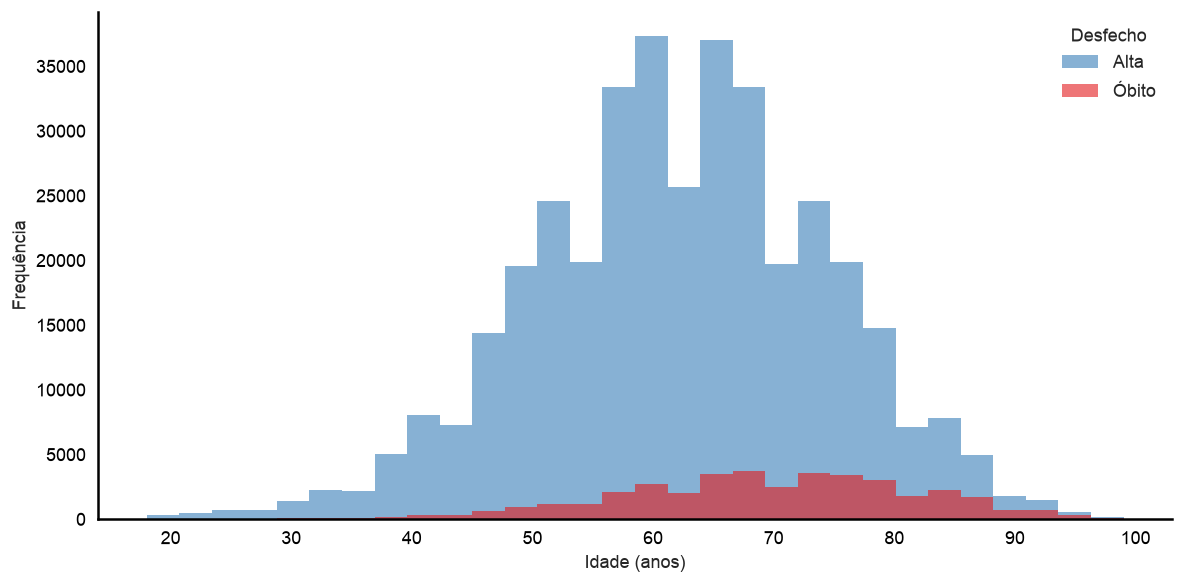

Figura salva: hist_idade.jpg


In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

desfechos = df['desfecho_label'].dropna().unique().tolist()

cores_def = ['#377EB8', '#E41A1C']

for desfecho, cor in zip(desfechos, cores_def):

    grp = df[df['desfecho_label'] == desfecho]

    ax.hist(
        grp['idade'].dropna(),
        bins=30,
        alpha=0.6,
        label=desfecho,
        color=cor,
        edgecolor='none'
    )

ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Frequência')

ax.legend(title='Desfecho', frameon=False)

ax.grid(False)

plt.tight_layout()

enforce_tcc_style()

plt.savefig(
    FIG_PATH / 'hist_idade.jpg',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Figura salva: hist_idade.jpg')

### 5.2 Boxplot de Tempo de Permanência por Desfecho

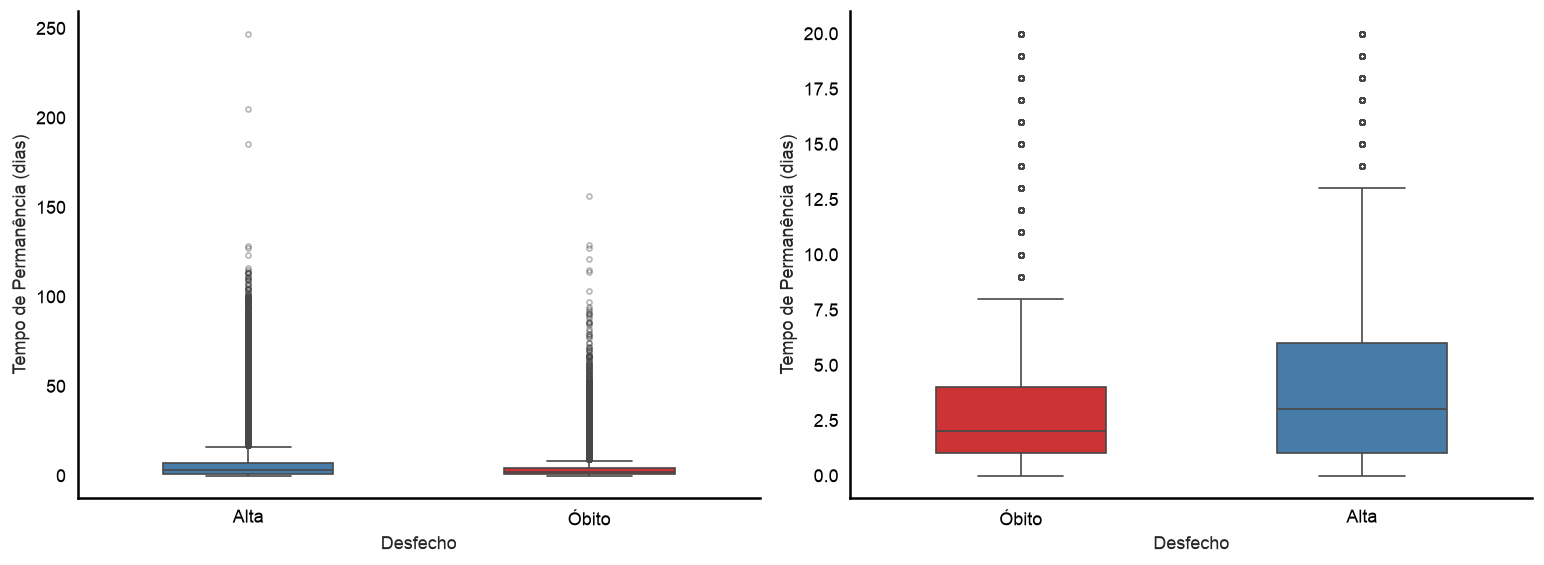

Figura salva: boxplot_permanencia_desfecho.jpg


In [15]:
import matplotlib.pyplot as plt
import numpy as np

palette_box = {
    'Alta': '#377EB8',    # azul
    'Óbito': '#E41A1C'    # vermelho
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Escala completa
import seaborn as sns
sns.boxplot(
    data=df, x='desfecho_label', y='dias_permanencia',
    hue='desfecho_label', palette=palette_box,
    width=0.5, legend=False,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[0]
)
# TÍTULO REMOVIDO — norma TCC
axes[0].set_xlabel('Desfecho')
axes[0].set_ylabel('Tempo de Permanência (dias)')
axes[0].grid(False)

# Sem outliers extremos (até p95)
p95 = df['dias_permanencia'].quantile(0.95)
df_sem_out = df[df['dias_permanencia'] <= p95]
sns.boxplot(
    data=df_sem_out, x='desfecho_label', y='dias_permanencia',
    hue='desfecho_label', palette=palette_box,
    width=0.5, legend=False,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=axes[1]
)
# TÍTULO REMOVIDO — norma TCC
axes[1].set_xlabel('Desfecho')
axes[1].set_ylabel('Tempo de Permanência (dias)')
axes[1].set_title(f'Sem outliers extremos (≤ p95 = {p95:.0f} dias)', fontsize=10, color='black', pad=4)
axes[1].grid(False)

plt.tight_layout()
enforce_tcc_style()
# Remover sub-título que enforce_tcc_style() apaga automaticamente para axes[1]
axes[1].set_title('')
plt.savefig(FIG_PATH / 'boxplot_permanencia_desfecho.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: boxplot_permanencia_desfecho.jpg')


### 5.3 Gráfico de Barras – Letalidade por Faixa Etária

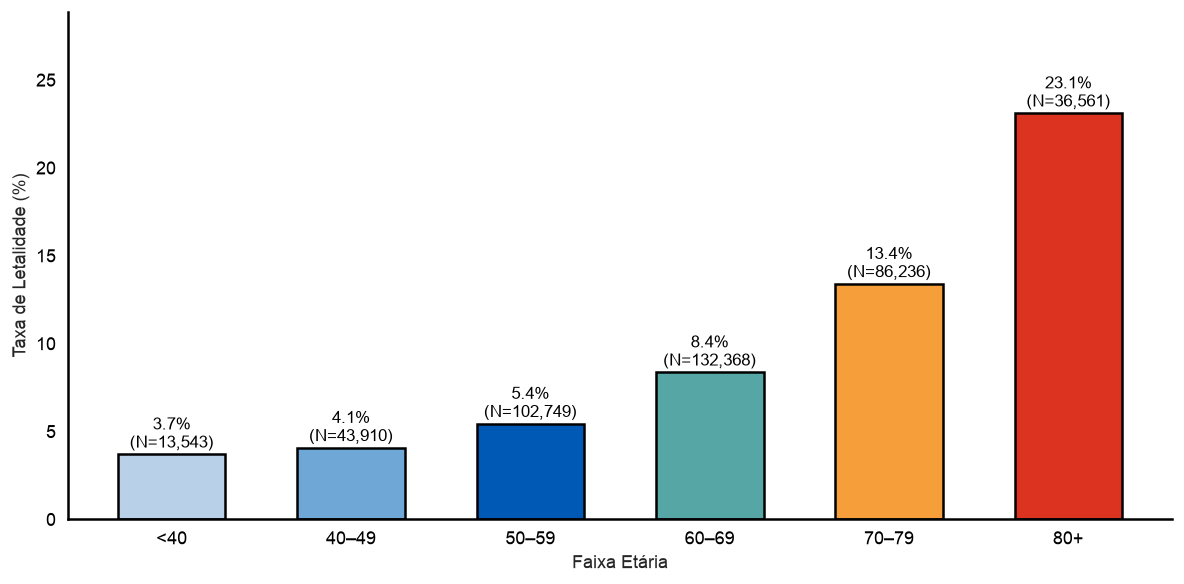

Figura salva: barras_letali_faixa_etaria.jpg


In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

cores_fx = [
    "#B8D0E8",  # azul muito claro
    "#6FA8D6",  # azul claro
    "#005AB5",  # azul
    "#56A6A6",  # azul-esverdeado
    "#F59E3A",  # laranja
    "#DC3220",  # vermelho
]

letali_fx = (
    df.groupby('faixa_etaria', observed=True)['indicador_obito']
    .agg(n_total='count', n_obitos='sum')
    .assign(
        taxa_letali=lambda x: (x['n_obitos'] / x['n_total']) * 100
    )
    .reset_index()
)

n_fx = len(letali_fx)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    letali_fx['faixa_etaria'].astype(str),
    letali_fx['taxa_letali'],
    color=cores_fx,
    edgecolor='black', linewidth=1.5, width=0.6
)

for bar, row in zip(bars, letali_fx.itertuples()):
    ax.annotate(
        f'{row.taxa_letali:.1f}%\n(N={row.n_total:,})',
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4), textcoords='offset points',
        ha='center', fontsize=10, color='black'
    )

# TÍTULO REMOVIDO — legenda abaixo no Word (norma TCC)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Taxa de Letalidade (%)')
ax.grid(False)
ax.set_ylim(0, letali_fx['taxa_letali'].max() * 1.25)

plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / 'barras_letali_faixa_etaria.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: barras_letali_faixa_etaria.jpg')


### 5.4 Mapa de Calor – Correlação entre Variáveis Numéricas

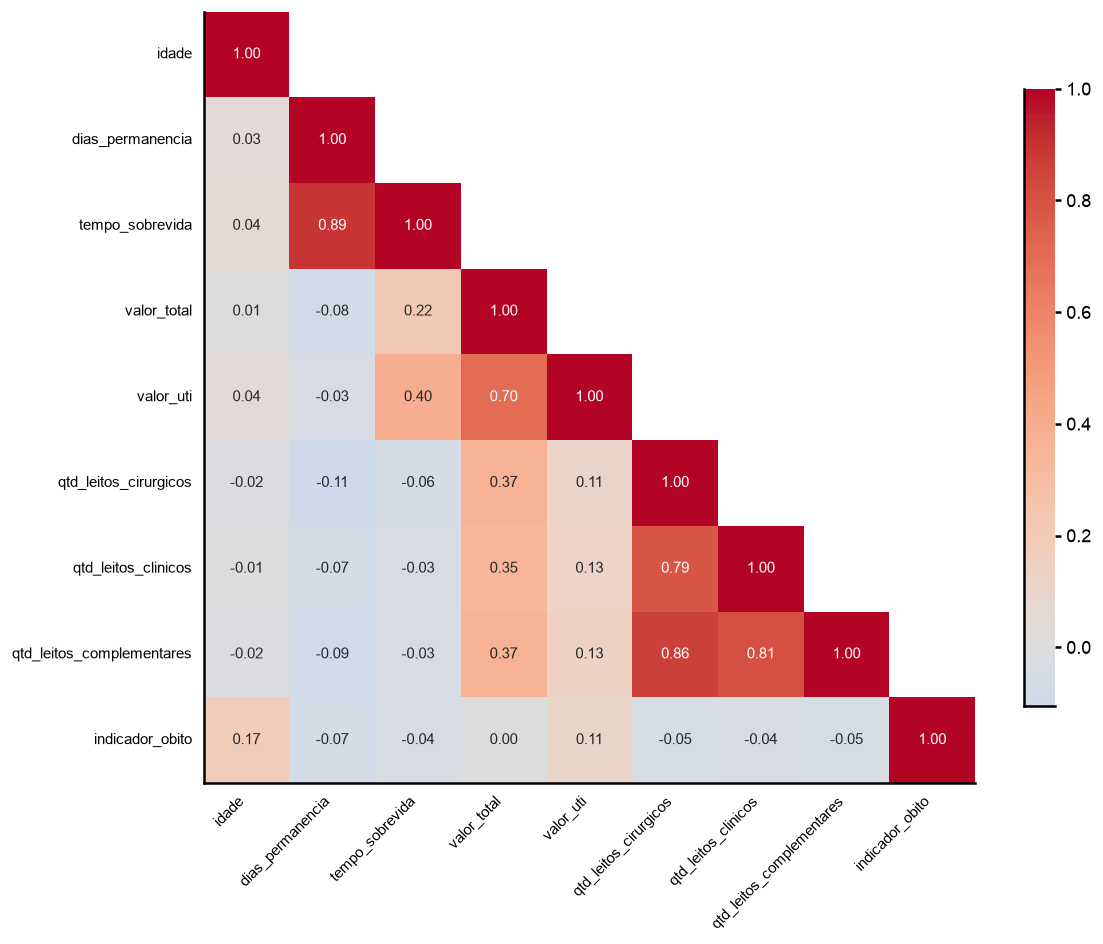

Figura salva: heatmap_correlacao.jpg


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

vars_num = [
    'idade', 'dias_permanencia', 'tempo_sobrevida',
    'uti_mes_total', 'valor_total', 'valor_uti',
    'qtd_leitos_cirurgicos', 'qtd_leitos_clinicos',
    'qtd_leitos_complementares', 'indicador_obito'
]
# Filtra apenas colunas que existem
vars_num = [c for c in vars_num if c in df.columns]

for c in vars_num:
    df[c] = pd.to_numeric(df[c], errors='coerce')

corr = df[vars_num].corr(method='pearson')

# Máscara triângulo superior
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask,
    cmap='coolwarm',       # viridis conforme padrão TCC
    center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0, linecolor='white',
    square=True, cbar_kws={'shrink': 0.8},
    ax=ax
)
# TÍTULO REMOVIDO — legenda abaixo no Word (norma TCC)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.grid(False)

plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / 'heatmap_correlacao.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: heatmap_correlacao.jpg')


---
## Resumo das Análises

| Item | Resultado |
|------|----------|
| Internações na base | ver célula 2 |
| Hospitais únicos (CNES) | ver célula 2 |
| Taxa de letalidade | ver célula 2 |
| Figura 1 – Histograma de Idade | `reports/figures/hist_idade.png` |
| Figura 2 – Boxplot Permanência × Desfecho | `reports/figures/boxplot_permanencia_desfecho.png` |
| Figura 3 – Letalidade por Faixa Etária | `reports/figures/barras_letali_faixa_etaria.png` |
| Figura 4 – Mapa de Calor Correlação | `reports/figures/heatmap_correlacao.png` |

> **Próximos passos:** notebook `04_modelagem.ipynb` – construção e avaliação dos modelos preditivos.